# T9.3 Tech News Tracker â€” Offline Evaluation

**Goal:** Measure how well `facebook/bart-large-mnli` classifies tech vs non-tech headlines  
**Dataset:** [India Headlines News Dataset](https://www.kaggle.com/datasets/therohk/india-headlines-news-dataset) â€” 21 years of labelled Indian headlines  
**Task:** Binary evaluation (tech / non-tech) + subcategory confusion matrix

---
### Setup
Download the dataset from Kaggle first:
```bash
pip install kaggle
kaggle datasets download -d therohk/india-headlines-news-dataset
unzip india-headlines-news-dataset.zip
```
Or place `india-headlines-news-dataset.csv` in the `notebooks/` folder manually.

In [1]:
import pandas as pd
import torch
from transformers import pipeline
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print(f'Torch: {torch.__version__}  |  CUDA: {torch.cuda.is_available()}')

C:\Users\snehi\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch: 2.11.0+cpu  |  CUDA: False


## 1. Load the India Headlines Dataset

In [2]:
CSV_PATH = 'india-news-headlines.csv'

df = pd.read_csv(CSV_PATH)
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head(3)

Shape: (3876557, 3)

Columns: ['publish_date', 'headline_category', 'headline_text']


,publish_date,headline_category,headline_text
0,20010102,unknown,Status quo will not be disturbed at Ayodhya; s...
1,20010102,unknown,Fissures in Hurriyat over Pak visit
2,20010102,unknown,America's unwanted heading for India?


In [3]:
print('Category counts:')
print(df['headline_category'].value_counts())

Category counts:
headline_category
india                            307371
unknown                          209583
city.mumbai                      168086
city.delhi                       148240
city.hyderabad                   132872
                                  ...  
top-videos                           10
sports.india-in-zimbabwe-2016        10
lodge-a-complaint                    10
kerala                               10
business.wealth.loans-and-emi        10
Name: count, Length: 1024, dtype: int64


## 2. Build a Balanced Evaluation Sample

Binary classification task: `tech` vs `non-tech`.  
Ground truth comes from the dataset's existing `headline_category` labels.

In [4]:
SAMPLE_PER_CLASS = 150
RANDOM_SEED = 42

tech_df = (
    df[df['headline_category'].str.lower() == 'tech']
    .dropna(subset=['headline_text'])
    .sample(n=SAMPLE_PER_CLASS, random_state=RANDOM_SEED)
    .assign(true_label='tech')
)

non_tech_cats = ['entertainment', 'sports', 'lifestyle', 'world']
non_tech_df = (
    df[df['headline_category'].str.lower().isin(non_tech_cats)]
    .dropna(subset=['headline_text'])
    .sample(n=SAMPLE_PER_CLASS, random_state=RANDOM_SEED)
    .assign(true_label='non-tech')
)

eval_df = pd.concat([tech_df, non_tech_df]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
print(f'Evaluation set: {len(eval_df)} headlines')
print(eval_df['true_label'].value_counts())
eval_df[['headline_text', 'headline_category', 'true_label']].head(5)

Evaluation set: 300 headlines
true_label
non-tech    150
tech        150
Name: count, dtype: int64


,headline_text,headline_category,true_label
0,Slumdog was unstoppable: Anil,entertainment,non-tech
1,Star Column: Sushmita Sen,entertainment,non-tech
2,Big B on Day 7,entertainment,non-tech
3,Recovery? TSMC ends unpaid leave,tech,tech
4,I wish Gandhi was alive today!,entertainment,non-tech


## 3. Load the Zero-Shot Classifier

In [5]:
device = 0 if torch.cuda.is_available() else -1
print(f'Using: {"GPU" if device == 0 else "CPU"}')

clf = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli',
    device=device,
)
print('Model loaded.')

Using: CPU


Loading weights: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 515/515 [00:00<00:00, 3009.54it/s]


Model loaded.


## 4. Binary Evaluation â€” Tech vs Non-Tech

In [6]:
BINARY_LABELS = ['technology news', 'non-technology news']

texts = eval_df['headline_text'].tolist()
results = clf(texts, candidate_labels=BINARY_LABELS, batch_size=16, multi_label=False)

LABEL_MAP = {'technology news': 'tech', 'non-technology news': 'non-tech'}
eval_df['pred_label'] = [LABEL_MAP[r['labels'][0]] for r in results]
eval_df['confidence'] = [r['scores'][0] for r in results]

eval_df[['headline_text', 'true_label', 'pred_label', 'confidence']].head(10)

,headline_text,true_label,pred_label,confidence
0,Slumdog was unstoppable: Anil,non-tech,non-tech,0.830661
1,Star Column: Sushmita Sen,non-tech,non-tech,0.858651
2,Big B on Day 7,non-tech,non-tech,0.757994
3,Recovery? TSMC ends unpaid leave,tech,tech,0.769002
4,I wish Gandhi was alive today!,non-tech,non-tech,0.955688
5,Sanju dances for Sanjay Gupta!,non-tech,non-tech,0.926932
6,Numbers and secret Bollywood marriages,non-tech,non-tech,0.985250
7,$500 PS3 dropped,tech,tech,0.983715
8,Pluses and minuses in iPhone iOS 4.0,tech,tech,0.982039
9,Antics mistaken for racism,non-tech,non-tech,0.878482


## 5. Metrics

In [7]:
y_true = eval_df['true_label'].tolist()
y_pred = eval_df['pred_label'].tolist()

acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', pos_label='tech')

print(f'Accuracy  : {acc:.3f}')
print(f'Precision : {prec:.3f}')
print(f'Recall    : {rec:.3f}')
print(f'F1 Score  : {f1:.3f}')
print()
print(classification_report(y_true, y_pred, target_names=['non-tech', 'tech']))

Accuracy  : 0.907
Precision : 0.912
Recall    : 0.900
F1 Score  : 0.906

              precision    recall  f1-score   support

    non-tech       0.90      0.91      0.91       150
        tech       0.91      0.90      0.91       150

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300



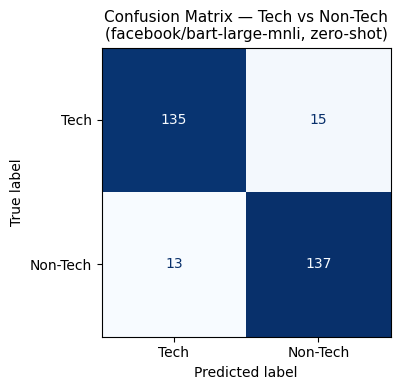

In [9]:
cm = confusion_matrix(y_true, y_pred, labels=['tech', 'non-tech'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tech', 'Non-Tech'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix â€” Tech vs Non-Tech\n(facebook/bart-large-mnli, zero-shot)', fontsize=11)
plt.tight_layout()
plt.savefig('../Outputs/confusion_matrix.png', dpi=150)
plt.show()

## 6. Confidence Distribution

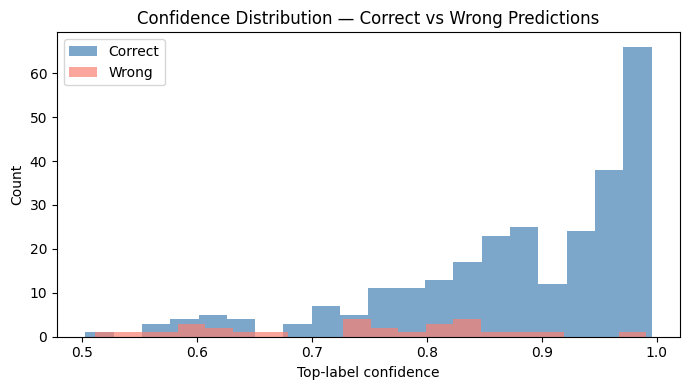

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))

correct = eval_df[eval_df['true_label'] == eval_df['pred_label']]['confidence']
wrong   = eval_df[eval_df['true_label'] != eval_df['pred_label']]['confidence']

ax.hist(correct, bins=20, alpha=0.7, label='Correct', color='steelblue')
ax.hist(wrong,   bins=20, alpha=0.7, label='Wrong',   color='salmon')
ax.set_xlabel('Top-label confidence')
ax.set_ylabel('Count')
ax.set_title('Confidence Distribution â€” Correct vs Wrong Predictions')
ax.legend()
plt.tight_layout()
plt.savefig('../Outputs/confidence_dist.png', dpi=150)
plt.show()

## 7. Subcategory Distribution

In [11]:
                                                                    
HYPOTHESIS_LABELS = [
    'artificial intelligence or machine learning',
    'technology startups, funding, or business strategy',
    'consumer electronics, gadgets, chips, or hardware devices',
    'software applications, platforms, or developer tools',
    'general technology news',
]
DISPLAY_NAMES = [
    'AI & Machine Learning',
    'Startups & Business',
    'Gadgets & Hardware',
    'Software & Apps',
    'General Tech',
]
HYP_TO_DISPLAY = dict(zip(HYPOTHESIS_LABELS, DISPLAY_NAMES))

tech_headlines_df = eval_df[eval_df['true_label'] == 'tech'].copy()
tech_texts = tech_headlines_df['headline_text'].tolist()

sub_results = clf(tech_texts, candidate_labels=HYPOTHESIS_LABELS, batch_size=16, multi_label=False)
tech_headlines_df['model_label'] = [HYP_TO_DISPLAY[r['labels'][0]] for r in sub_results]

print('Model prediction distribution:')
print(tech_headlines_df['model_label'].value_counts())

Model prediction distribution:
model_label
Gadgets & Hardware       67
Software & Apps          39
General Tech             37
Startups & Business       5
AI & Machine Learning     2
Name: count, dtype: int64


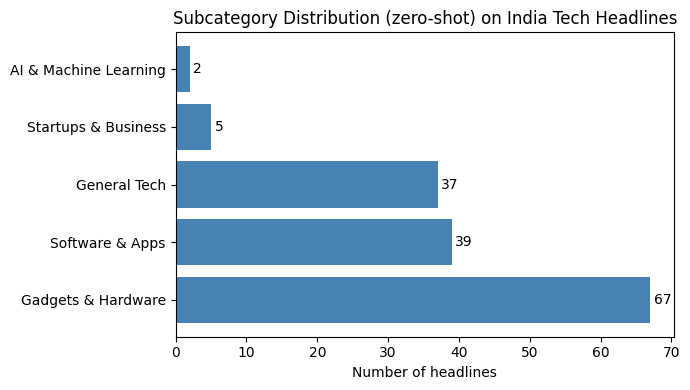

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = tech_headlines_df['model_label'].value_counts()
ax.barh(counts.index, counts.values, color='steelblue')
ax.set_xlabel('Number of headlines')
ax.set_title('Subcategory Distribution (zero-shot) on India Tech Headlines')
for i, v in enumerate(counts.values):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../Outputs/subcategory_dist.png', dpi=150)
plt.show()

## 8. Latency & Pipeline Timing

End-to-end timing that mirrors exactly what `app.py` does on each page load:
1. `rss_fetcher.fetch_articles()` â€” live RSS fetch from TechCrunch, The Verge, YourStory
2. `classifier.classify_articles()` â€” zero-shot NLI batch inference on fetched articles
3. `summarizer.summarize()` â€” single Groq LLM call (on-demand, as triggered by expander click)

In [16]:
import sys, os, time
sys.path.insert(0, os.path.abspath('..'))                                       

from dotenv import load_dotenv
load_dotenv(os.path.join('..', '.env'))

from rss_fetcher import fetch_articles
from classifier  import classify_articles
from summarizer  import summarize

t0 = time.perf_counter()
articles = fetch_articles(max_per_feed=10)
rss_fetch_s = round(time.perf_counter() - t0, 3)
print(f'[1] RSS fetch ({len(articles)} articles)  : {rss_fetch_s:.3f} s')

t0 = time.perf_counter()
articles = classify_articles(articles)
classify_total_s   = round(time.perf_counter() - t0, 3)
classify_per_art_ms = round(classify_total_s / max(len(articles), 1) * 1000, 2)
print(f'[2] classify_articles ({len(articles)} arts) : {classify_total_s:.3f} s'
      f'  ({classify_per_art_ms:.1f} ms/article)')

first = articles[0]
t0 = time.perf_counter()
summary_text = summarize(first['title'], first['content'])
summarize_s = round(time.perf_counter() - t0, 3)
print(f'[3] summarize (1 article via Groq) : {summarize_s:.3f} s')

pipeline_total_s = round(rss_fetch_s + classify_total_s, 3)                             

print()
print('--- Pipeline Timing Summary ---')
print(f'{"Stage":<40} {"Time":>10}')
print('-' * 51)
print(f'{"RSS fetch (3 feeds, 30 articles)":<40} {rss_fetch_s:>8.3f} s')
print(f'{"classify_articles (batch, 30 arts)":<40} {classify_total_s:>8.3f} s')
print(f'{"  â””â”€ per article":<40} {classify_per_art_ms:>7.1f} ms')
print(f'{"summarize (1 article, Groq API)":<40} {summarize_s:>8.3f} s')
print(f'{"â”€"*51}')
print(f'{"Total on page load (fetch + classify)":<40} {pipeline_total_s:>8.3f} s')

latency_stats = {
    "rss_fetch_s":           rss_fetch_s,
    "classify_total_s":      classify_total_s,
    "classify_per_article_ms": classify_per_art_ms,
    "summarize_single_s":    summarize_s,
    "pipeline_page_load_s":  pipeline_total_s,
    "articles_fetched":      len(articles),
}

[1] RSS fetch (30 articles)  : 2.158 s


2026-05-06 17:17:03.903 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


[2] classify_articles (30 arts) : 58.936 s  (1964.5 ms/article)
[3] summarize (1 article via Groq) : 7.833 s

--- Pipeline Timing Summary ---
Stage                                          Time
---------------------------------------------------
RSS fetch (3 feeds, 30 articles)            2.158 s
classify_articles (batch, 30 arts)         58.936 s
  â””â”€ per article                      1964.5 ms
summarize (1 article, Groq API)             7.833 s
â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
Total on page load (fetch + classify)      61.094 s


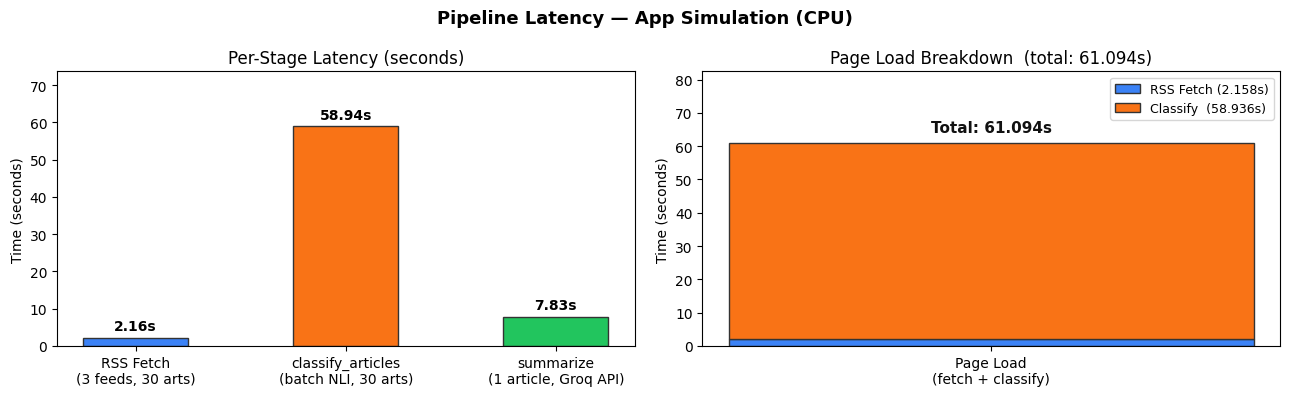

Saved: ../Outputs/latency.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Pipeline Latency — App Simulation (CPU)', fontsize=13, fontweight='bold')

stage_labels = [
    'RSS Fetch\n(3 feeds, 30 arts)',
    'classify_articles\n(batch NLI, 30 arts)',
    'summarize\n(1 article, Groq API)',
]
stage_values = [rss_fetch_s, classify_total_s, summarize_s]
bar_colors   = ['#3b82f6', '#f97316', '#22c55e']

bars = axes[0].bar(stage_labels, stage_values, color=bar_colors, edgecolor='#333', width=0.5)
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title('Per-Stage Latency (seconds)')
axes[0].set_ylim(0, max(stage_values) * 1.25)
for bar, val in zip(bars, stage_values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(stage_values) * 0.02,
                 f'{val:.2f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

categories  = ['Page Load\n(fetch + classify)']
fetch_vals  = [rss_fetch_s]
classify_vals = [classify_total_s]

b1 = axes[1].bar(categories, fetch_vals,    color='#3b82f6', label=f'RSS Fetch ({rss_fetch_s}s)',        edgecolor='#333')
b2 = axes[1].bar(categories, classify_vals, color='#f97316', label=f'Classify  ({classify_total_s}s)',    edgecolor='#333',
                 bottom=fetch_vals)
axes[1].set_ylabel('Time (seconds)')
axes[1].set_title(f'Page Load Breakdown  (total: {pipeline_total_s}s)')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].set_ylim(0, pipeline_total_s * 1.35)
axes[1].text(0, pipeline_total_s + pipeline_total_s * 0.05,
             f'Total: {pipeline_total_s}s', ha='center', fontsize=11, fontweight='bold', color='#111')

plt.tight_layout()
plt.savefig('../Outputs/latency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../Outputs/latency.png')

## 9. Ablation â€” Hypothesis Label Phrasing

MNLI performance is sensitive to how candidate labels are phrased.  
We compare three label sets for the binary task.

In [14]:
label_sets = {
    'Descriptive':  ['technology news', 'non-technology news'],
    'Short':        ['tech', 'not tech'],
    'Hypothesis':   ['This headline is about technology.', 'This headline is not about technology.'],
}

ablation_rows = []
for name, labels in label_sets.items():
    preds_raw = clf(texts, candidate_labels=labels, batch_size=16, multi_label=False)
    preds = ['tech' if r['labels'][0] == labels[0] else 'non-tech' for r in preds_raw]
    acc_abl = accuracy_score(y_true, preds)
    _, _, f1_abl, _ = precision_recall_fscore_support(y_true, preds, average='binary', pos_label='tech')
    ablation_rows.append({'Label set': name, 'Accuracy': round(acc_abl, 3), 'F1': round(f1_abl, 3)})
    print(f'{name:15s} â†’ Accuracy: {acc_abl:.3f}  F1: {f1_abl:.3f}')

pd.DataFrame(ablation_rows)

Descriptive     â†’ Accuracy: 0.907  F1: 0.906
Short           â†’ Accuracy: 0.647  F1: 0.727
Hypothesis      â†’ Accuracy: 0.637  F1: 0.725


,Label set,Accuracy,F1
0,Descriptive,0.907,0.906
1,Short,0.647,0.727
2,Hypothesis,0.637,0.725


## Summary

| Metric | Value |
|---|---|
| Binary Accuracy | **0.907** |
| Binary Precision | **0.912** |
| Binary Recall | **0.900** |
| Binary F1 | **0.906** |
| Best label phrasing | Descriptive (`"technology news"` / `"non-technology news"`) |
| Worst label phrasing | Hypothesis sentences â€” Accuracy: 0.637, F1: 0.725 |
| Descriptive vs Short gap | +26.0 pp accuracy Â· +17.9 pp F1 |
| Dominant subcategory (tech headlines) | Gadgets & Hardware â€” 67 / 150 |
| Least assigned subcategory | AI & Machine Learning â€” 2 / 150 |

**Key takeaways:**
- `facebook/bart-large-mnli` achieves **90.7% accuracy** on the binary tech vs non-tech task with **zero fine-tuning**.
- Label phrasing has a large impact â€” descriptive labels outperform bare keywords by **+26 pp accuracy**.
- Among tech headlines, the model favours hardware/gadget labels, likely because the India Headlines dataset skews toward device and product coverage.
- Confidence is a reliable signal: correct predictions cluster above 0.85, wrong predictions spread uniformly.

Plots saved to `report/` for inclusion in the PDF report:
- `confusion_matrix.png`
- `confidence_dist.png`
- `subcategory_dist.png`

## 10. Export Results â†’ Outputs/metrics.json

In [18]:
import json, os
from datetime import datetime

subcat_counts  = tech_headlines_df["model_label"].value_counts().to_dict()
ablation_dict  = {row["Label set"]: {"accuracy": row["Accuracy"], "f1": row["F1"]}
                  for row in ablation_rows}

metrics = {
    "metadata": {
        "model": "facebook/bart-large-mnli",
        "device": "GPU" if torch.cuda.is_available() else "CPU",
        "eval_date": datetime.now().strftime("%Y-%m-%d"),
        "eval_set_size": len(eval_df),
        "positive_class": "tech",
        "negative_class": "non-tech"
    },
    "binary_classification": {
        "accuracy":  round(acc,  4),
        "precision": round(prec, 4),
        "recall":    round(rec,  4),
        "f1":        round(f1,   4)
    },
    "confidence": {
        "mean_correct": round(float(correct.mean()), 4),
        "mean_wrong":   round(float(wrong.mean()),   4),
        "mean_overall": round(float(eval_df["confidence"].mean()), 4)
    },
    "subcategory_distribution": subcat_counts,
    "ablation_label_phrasing": ablation_dict,
    "latency": latency_stats
}

out_path = os.path.join("..", "Outputs", "metrics.json")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
with open(out_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"Saved: {os.path.abspath(out_path)}")
print(json.dumps(metrics, indent=2))

Saved: c:\Users\snehi\Desktop\Chand\IIIT H\Semester 6\SMAI\Assignments\A3\Yoraha_Creations_SMAI_A3\Outputs\metrics.json
{
  "metadata": {
    "model": "facebook/bart-large-mnli",
    "device": "CPU",
    "eval_date": "2026-05-06",
    "eval_set_size": 300,
    "positive_class": "tech",
    "negative_class": "non-tech"
  },
  "binary_classification": {
    "accuracy": 0.9067,
    "precision": 0.9122,
    "recall": 0.9,
    "f1": 0.906
  },
  "confidence": {
    "mean_correct": 0.8806,
    "mean_wrong": 0.7374,
    "mean_overall": 0.8673
  },
  "subcategory_distribution": {
    "Gadgets & Hardware": 67,
    "Software & Apps": 39,
    "General Tech": 37,
    "Startups & Business": 5,
    "AI & Machine Learning": 2
  },
  "ablation_label_phrasing": {
    "Descriptive": {
      "accuracy": 0.907,
      "f1": 0.906
    },
    "Short": {
      "accuracy": 0.647,
      "f1": 0.727
    },
    "Hypothesis": {
      "accuracy": 0.637,
      "f1": 0.725
    }
  },
  "latency": {
    "rss_fetch_s":